#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import anndata as ad
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = './'
outdir = './plots'

In [ ]:
genes_df = pd.read_csv('../../../03.data/01.ref/mm10.genes.bed', sep='\t', header=None, names=['chromosome', 'start', 'end', 'gene_id', 'gene_name', 'gene_type', 'strand'])

In [ ]:
state="hyper"

subclass_list = pd.read_csv('../../../03.data/04.config_files/subclass_order.csv', header=None)[0].to_list()
subclass_list=[i for i in subclass_list if "NN" not in i]

df_RNA=pd.read_csv('../../03.Joint-Cabernet.cellType_State/04-Correlation_calculation/all_cell_correlation/02-our_subclass_mean_dat_final.csv',index_col=0).T.loc[subclass_list,:]

df_frac_segment_subclass=dict()
df_frac_segment_subclass["5hmCG"]=ad.read_h5ad('5hmC_merged_allc_with_5hmC_segment.h5ad').to_df().iloc[:len(subclass_list),:]
df_frac_segment_subclass["5hmCG"].index=df_RNA.index

DMR_states_df=ad.read_h5ad('../../04.subclass.DMR/03-stratified_RankSumTest_1vsOthers/01_subclasses_in_neuron_1vsOthers/5hmCG_DMR_states_neuron_1vsOthers.h5ad').to_df()

if state == "hyper":
    segment_differential_states=(DMR_states_df==1).sum(axis=0)
elif state == "hypo":
    segment_differential_states=(DMR_states_df==-1).sum(axis=0)
elif state == "all":
    segment_differential_states=(DMR_states_df.abs()==1).sum(axis=0)

differential_segments=segment_differential_states[segment_differential_states>0].index

def get_midpoint_bin(segment_):
    chrom_, start_, end_ = segment_.split("_")
    return int((int(end_)+int(start_)-1)/2/10_000)                        

differential_segments_by_chrom={chrom_ : [(i, get_midpoint_bin(i)) for i in differential_segments if i.split("_")[0]==chrom_] for chrom_ in ["chr"+str(j) for j in range(1,20)]}

In [5]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import cooltools
import cooler

In [6]:
import datetime
from matplotlib.colors import LogNorm

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = "/arial/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
subclass_list=['DG Glut', 'Pvalb Gaba'] # just the two subclasses for display
csv_path = "../../../03.data/02.metainfo/01.Young_Mouse/subclass_name.Joint_Cabernet_corresponding_to_3C.csv"
df = pd.read_csv(csv_path, sep=',')
df = df[df['subclass_our'].apply(lambda x : x in subclass_list)]
df

,subclass_our,subclass_liu
15,DG Glut,DG_Glut
21,Pvalb Gaba,Pvalb_Gaba


In [9]:
# Vwc2 has been selected based on 'selected_loops.csv' and visual examination.
genes_df[genes_df['gene_name']=='Vwc2']

,chromosome,start,end,gene_id,gene_name,strand
32302,chr11,11114223,11268931,ENSMUSG00000050830.17,Vwc2,+


In [ ]:
# load the 3C data
print(f"initialization started  at {datetime.datetime.now()}")
resolution_=10_000

mcool_file={subclass_liu : f'{subclass_liu}.Q.10K.mcool'
           for subclass_liu in df['subclass_liu']}
clr={subclass_Nature : cooler.Cooler(f'{mcool_file[subclass_Nature]}::resolutions/{resolution_}') for subclass_Nature in df['subclass_liu']}
matrixes_={
    chrom_ : 
           [
               clr[subclass_Nature].matrix(balance=True).fetch(chrom_)[:] 
                     for subclass_Nature in df['subclass_liu']
           ] 
           for chrom_ in ["chr"+str(i) for i in [11] ] # only relevant chromosomes are loaded
}
print(f"initialization finished at {datetime.datetime.now()}")

initialization started  at 2025-11-20 16:43:12.162226
initialization finished at 2025-11-20 16:43:18.992072


<Figure size 118.11x118.11 with 0 Axes>

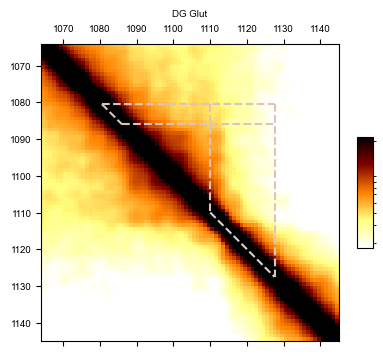

<Figure size 118.11x118.11 with 0 Axes>

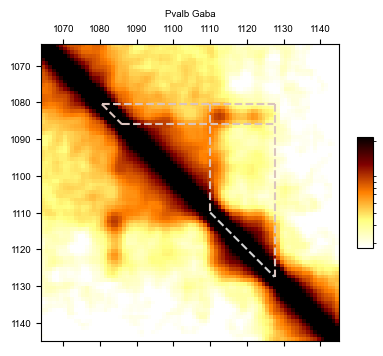

In [11]:
gene_name_ = 'Vwc2'
gene_ = genes_df[genes_df["gene_name"]==gene_name_]
chrom_, gene_start_, gene_end_, strand_ = gene_.loc[:,["chromosome","start","end","strand"]].iloc[0,:]
gene_start_, gene_end_ = map(int, (gene_start_, gene_end_))
(TSS_, TES_) =(gene_start_, gene_end_)[::(2*(strand_=='+')-1)]
plot_lower_bin=1079-15
plot_upper_bin=1130+15
# plt.matshow works like range(start_, end_). The upper bin itself will not be shown, its start is the right border.
distal_lower, distal_upper, gene_lower, gene_upper = 1080.5, 1086, 1110, 1127.5

for cmap_ in ['afmhot_r']: #['fall', 'afmhot_r', 'hot_r', 'inferno_r', 'YlOrBr', 'gist_heat_r', 'Reds', 'OrRd']:
    for subclass_ in subclass_list:
        plt.figure(figsize=(30/25.4, 30/25.4))
        plt.matshow(matrixes_[chrom_][subclass_list.index(subclass_)]\
                       [plot_lower_bin : plot_upper_bin, plot_lower_bin : plot_upper_bin],
                       extent=[plot_lower_bin , plot_upper_bin , plot_upper_bin, plot_lower_bin],
                       norm=LogNorm(vmax=0.022, vmin=0.0018), cmap=cmap_)
        cb = plt.colorbar(shrink=0.3, aspect=7,ticks=[])
        color_for_guide_line='#DBC4BE'
        plt.hlines([distal_lower], distal_lower , gene_upper, color=color_for_guide_line, linestyles='dashed')
        plt.hlines([distal_upper], distal_upper , gene_upper, color=color_for_guide_line, linestyles='dashed')
        plt.vlines([gene_lower], distal_lower , gene_lower, color=color_for_guide_line, linestyles='dashed')
        plt.vlines([gene_upper], distal_lower , gene_upper, color=color_for_guide_line, linestyles='dashed')
        plt.plot((distal_lower, distal_upper), (distal_lower, distal_upper), color=color_for_guide_line, linestyle='dashed')
        plt.plot((gene_lower, gene_upper), (gene_lower, gene_upper), color='lightgrey', linestyle='dashed')
        plt.title(f'{subclass_}', fontdict={'size':7});
        plt.xticks(fontsize=7); plt.yticks(fontsize=7)
        plt.savefig(f'{outdir}/plot_Vwc2-{cmap_}-{subclass_}.pdf')
        plt.savefig(f'{outdir}/plot_Vwc2-{cmap_}-{subclass_}.png', dpi=600)
        plt.show()